# Анализ продаж интернет-магазина видеоигр

# Цель проекта
Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Необходимо выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

# Документация
- Данные продаж до 2016 года - /datasets/games.csv
- Name — название игры
- Platform — платформа
- Year_of_Release — год выпуска
- Genre — жанр игры
- NA_sales — продажи в Северной Америке (миллионы проданных копий)
- EU_sales — продажи в Европе (миллионы проданных копий)
- JP_sales — продажи в Японии (миллионы проданных копий)
- Other_sales — продажи в других странах (миллионы проданных копий)
- Critic_Score — оценка критиков (максимум 100)
- User_Score — оценка пользователей (максимум 10)
- Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.


# Этапы исследования
1. Загрузка данных/разведовательный анализ 
2. Предобработка
3. EDA
4. Составление портрета пользователя каждого региона
5. Проверка гипотез
6. Общий вывод

# Загрузка данных/разведовательный анализ

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import scipy.stats as st
!pip install missingno
import missingno as msno # импорт инструментов для работы

In [2]:
data = pd.read_csv("/datasets/games.csv") # загрузка данных в датафрейм
data # просмотр фрейма

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [3]:
data.info() # просмотр информации о фрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
data.describe() # просмотр информации о фрейме

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


Данные представлены датафреймом, 11 полей, 16715 строк, сложно сказать что либо о наличии пропусков и дубликатов, рассмотрим их в дальнейших шагах но в фрейме замечены поля с несоответствующим типом данных Year_of_Release (float64) и User_Score (object) , замену сделаем в следующих шагах.

# Предобработка

In [5]:
data.isnull().sum() # поиск пропусков 

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

Зарегистрированы пропуски в Name, Genre, Year_of_Release. Особо крупные потери в  Critic_Score, User_Score, Rating   

In [6]:
data.duplicated().sum() # поиск дубликатов 

0

Явные дубликаты не обнаружены

In [7]:
data.columns = data.columns.str.lower() # приведение к нижнему регистру 

In [8]:
data[data[['name', 'platform','year_of_release']].duplicated(keep=False)] # поиск неявных дубликатов 

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012.0,Sports,2.11,0.22,0.00,0.23,83.0,5.5,E
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN
16230,Madden NFL 13,PS3,2012.0,Sports,0.00,0.01,0.00,0.00,83.0,5.5,E


In [9]:
data["year_of_release"] = pd.array(data["year_of_release"], dtype = pd.Int64Dtype()) # замена на корректный тип данных

Тип данных замёнен на целое число

In [10]:
data["year_of_release"].min() # поиск минимального значения по полю

1980

In [11]:
data["year_of_release"].max() # поиск максимального значения по полю

2016

Теперь нам известен диапазон по времени в нашем датасете. В данном поле 260 пропусков, заменить пропуски за счёт других полей не получится, не уверен что стоит заполнять пропуски средними значениями, оставлю пока как есть.

In [12]:
data["user_score"].value_counts() # поиск уникальных значений 

tbd    2424
7.8     324
8       290
8.2     282
8.3     254
       ... 
0.9       2
9.6       2
0.6       2
9.7       1
0         1
Name: user_score, Length: 96, dtype: int64

В данном случае tbd это обозначение ("будет определено"), данное поле логичнее перевести в формат float и изменим значение на NaN. Прочие пропуски оставим в столбце без изменений так как у нас нет возможности их восполнить за счёт чего либо

In [13]:
data["user_score"] = pd.to_numeric(data["user_score"], errors = "coerce") # замена на Nan

In [14]:
data["name"].value_counts() # поиск уникальных значений

Need for Speed: Most Wanted                            12
FIFA 14                                                 9
Madden NFL 07                                           9
LEGO Marvel Super Heroes                                9
Ratatouille                                             9
                                                       ..
Harukanaru Toki no Naka de 3 with Izayoiki Aizouban     1
Tokyo Xtreme Racer Advance                              1
Uncharted: Drake's Fortune                              1
Namco Museum Vol.3                                      1
Timmy Time                                              1
Name: name, Length: 11559, dtype: int64

Для удобства приведём всё к нижнему регистру + нужно разобратся, почему игры не уникальны

In [15]:
data["name"] = data["name"].str.lower() # приведение к нижнему регистру  

In [16]:
game_names = data.query("name == 'cars'") # создание списка
game_names

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1651,cars,PS2,2006,Racing,1.01,0.04,0.0,0.16,71.0,8.4,E
1685,cars,PSP,2006,Racing,0.72,0.28,0.0,0.20,70.0,7.0,E
1805,cars,GBA,2006,Racing,0.81,0.30,0.0,0.02,50.0,4.7,E
2127,cars,DS,2006,Racing,0.85,0.04,0.0,0.07,54.0,2.1,E
2227,cars,GC,2006,Racing,0.72,0.19,0.0,0.03,71.0,7.0,E
2244,cars,Wii,2006,Racing,0.83,0.03,0.0,0.07,65.0,NaN,E
6668,cars,X360,2006,Racing,0.22,0.01,0.0,0.02,65.0,6.1,E
7567,cars,XB,2006,Racing,0.15,0.04,0.0,0.01,70.0,NaN,E


Игра выпускается срау на несколько платформ, поэтому может соотвествовать нескольким записям. Посмотрим на пропущенные значения в этом столбце

In [17]:
nan_name = data[data["name"].isnull()] # создание списка с Nan
nan_name

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


В строках в целом большое количество пропусков и по другим полям, думаю можно их удалить.

In [18]:
data.dropna(subset = ["name"], inplace = True) # удаление

Перейдём к полю rating

In [19]:
data["rating"].unique() # просмотр уникальных значений

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

В данном поле указаны рейтинги, заменим буквенные обозначения на что то более понятное 

In [20]:
rating_list = {"E": "Все",
                  "M": "Взрослые",
                  "T": "Подростки",
                  "E10+": "От 10 лет",
                  "AO": "Только взрослые",
                  "EC": "Младший возраст",
                  "RP": "Рейтинг ожидается"} # подготовка списка для замены

data["rating"] = data["rating"].replace(rating_list) # замена значений в rating

в поле rating всё ещё остались пропуски, опять таки у нас нет возможности их восполнить, оставим как есть

In [21]:
data # просмотр фрейма

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,Все
1,super mario bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,mario kart wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,Все
3,wii sports resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,Все
4,pokemon red/pokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,samurai warriors: sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,lma manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,spirits & spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


следующим шагом посчитаем продажи по регионам и создадим отдельное поле

In [22]:
data["total"] = data["na_sales"] + data["eu_sales"] + data["jp_sales"] + data["other_sales"] # суммируем продажи
data # просмотр фрейма

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total
0,wii sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,Все,82.54
1,super mario bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,mario kart wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,Все,35.52
3,wii sports resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,Все,32.77
4,pokemon red/pokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,samurai warriors: sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,lma manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16712,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16713,spirits & spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01


На этапе предобработки мы изменили типы данных в столбцах user_score и year_of_release, привели названия столбцов и значения в столбце name к нижнему регистру, а также скорректировали значения rating для удобства анализа. Добавили новый столбец rating с суммарными продажами по регионам. Удалили два пропуска в столбцах name и genre, которые оказались в одних строках. Анализ пропусков в остальных столбцах показал, что их удаление пока не требуется

# EDA

Рассмотрим распределение выпущенных игр по года. 

In [23]:
games = data.groupby("year_of_release").size() # подготовка списка для построения графика распределения 

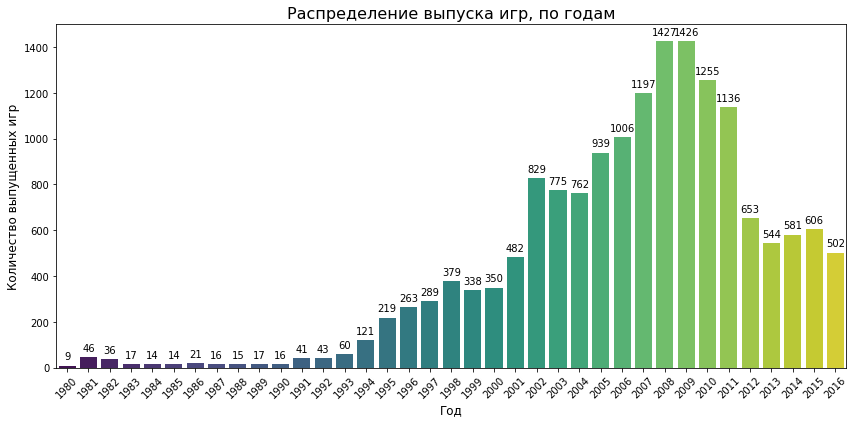

In [24]:
plt.figure(figsize = (12, 6)) # проектирование графика
ax = sns.barplot(x = games.index, y = games.values, palette = "viridis")
plt.title("Распределение выпуска игр, по годам", fontsize = 16)
plt.xlabel("Год", fontsize = 12)
plt.ylabel("Количество выпущенных игр" , fontsize=12)
plt.xticks(rotation = 45)

for p in ax.patches:
    ax.annotate(format(p.get_height(), ".0f"), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = "center", va = "center", 
                xytext = (0, 9), 
                textcoords = "offset points")

plt.tight_layout()
plt.show()

На графике видно, что, за исключением небольшого роста в 1981–1982 годах, индустрия игр оставалась относительно стабильной до начала 1990-х. Затем начался рост, достигший пика в 2008–2009 годах, после чего наблюдается резкое снижение — менее половины исходных значений к концу периода. Поэтому данные до 1995 года можно считать несущественными для анализа. Следующим шагом рассмотрим продажи по платформам

<div style="font-family: Georgia, serif; background: rgba(220, 250, 230, 0.85); color: #213f2c; padding: 16px 22px; margin: 16px 0; border-left: 5px solid #48a078; border-radius: 14px; box-shadow: 0 8px 14px rgba(0, 0, 0, 0.15); backdrop-filter: blur(2px);">
<b>Комментарий ревьюера v.1</b><br><br>
👍 
Верно
</div>

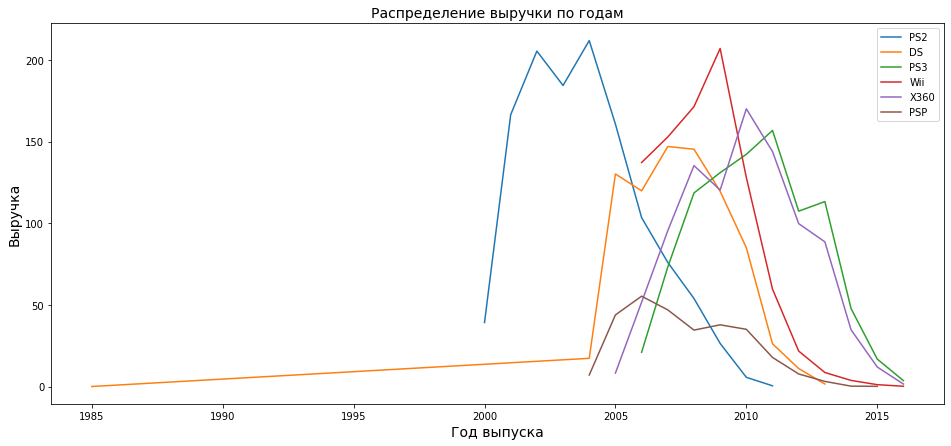

In [25]:
top_platform = data.groupby("platform")["total"].count().sort_values(ascending=False).head(6)
filtered = data[data["platform"].isin(top_platform.index)]
sales = filtered.groupby(["year_of_release", "platform"])["total"].sum().reset_index()

plt.figure(figsize=(16, 7))
for platform in top_platform.index:
    platform_data = sales[sales["platform"] == platform] # группировка, фильтрация, визуализация
    plt.plot(platform_data["year_of_release"], platform_data["total"], label = platform)

plt.title("Распределение выручки по годам", fontsize = 14)
plt.xlabel("Год выпуска", fontsize = 14)
plt.ylabel("Выручка", fontsize = 14)
plt.legend()
plt.show() 

На графике видно, что каждая платформа существует примерно 10 лет. Для PS заметно, как новые версии заменяют предыдущие, а платформа DS остается единственной на протяжении всего периода.

Исходя из анализа выпуска игр и выручки за последние годы, учитывая быстрое развитие индустрии, для прогноза на 2017 год возьмем период с 2012 по 2016 годы (5 лет), исключая данные до 2012 года.

In [26]:
release_2012 =  data.query("year_of_release > 2011").reset_index() # делаем необходимый срез данных
release_2012

,index,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total
0,16,grand theft auto v,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,Взрослые,21.05
1,23,grand theft auto v,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,Взрослые,16.27
2,31,call of duty: black ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
3,33,pokemon x/pokemon y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
4,34,call of duty: black ops ii,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,Взрослые,13.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881,16703,strawberry nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
2882,16707,aiyoku no eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
2883,16710,samurai warriors: sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
2884,16712,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


Следующим шагом построим график распределения продаж по платформам и годам

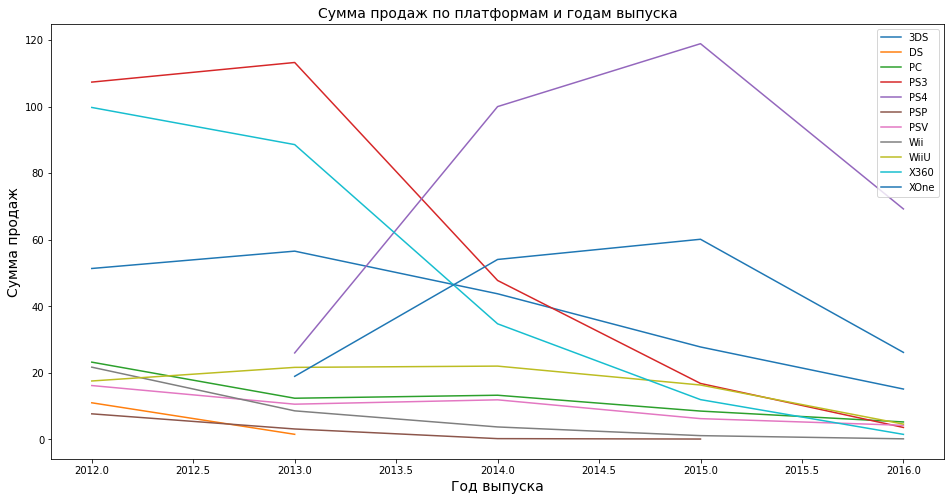

In [27]:
sales_platform_year = release_2012.groupby(["platform", "year_of_release"])["total"].sum().reset_index()

plt.figure(figsize = (16, 8)) 
for platform in sales_platform_year["platform"].unique():
    platform_data = sales_platform_year[sales_platform_year["platform"] == platform] # группировка по данных по году
    plt.plot(platform_data["year_of_release"], platform_data["total"], label = platform)

plt.title("Сумма продаж по платформам и годам выпуска", fontsize = 14)
plt.xlabel("Год выпуска", fontsize = 14)
plt.ylabel("Сумма продаж", fontsize = 14)
plt.legend()
plt.show()

In [28]:
top_sales_platform = release_2012.groupby("platform")["total"].sum().reset_index().sort_values(by = "total", ascending = False).head(6)
top_sales_platform # группировка по платфлорме и сумме

,platform,total
4,PS4,314.14
3,PS3,288.79
9,X360,236.54
0,3DS,194.61
10,XOne,159.32
8,WiiU,82.19


Самые прибыльные — PS4, XOne и 3DS. За весь период лидерами по выручке остаются PS4, PS3, X360, 3DS, XOne и WiiU.

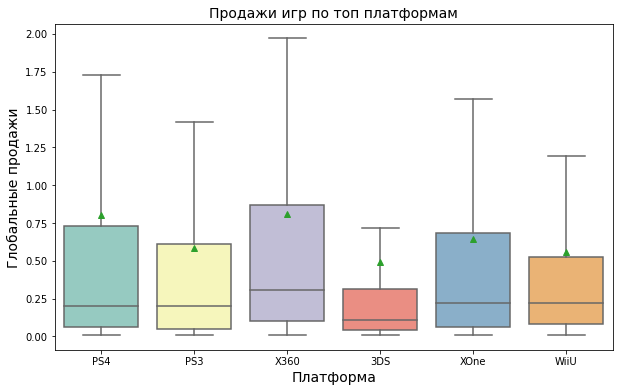

In [29]:
platforms = ["X360", "PS3", "WiiU", "3DS", "XOne", "PS4"] # фильтрация, сортировка
filtered = release_2012[release_2012["platform"].isin(platforms)]
sort = filtered.groupby("platform")["total"].sum().sort_values(ascending=False).index


plt.figure(figsize = (10, 6)) # Проектирование графика
sns.boxplot(data = filtered , y = "total", x = "platform", order = sort, showfliers = False, showmeans = True, palette = "Set3")
plt.title("Продажи игр по топ платформам", fontsize = 14)
plt.xlabel("Платформа", fontsize = 14)
plt.ylabel("Глобальные продажи", fontsize = 14)
plt.show()

Медианная сумма продаж по топовым платформам составляет от 0,15 до 0,28 млн за игру. В выбросах выделяется X360 с максимумом около 1,95 млн. У PS4, PS3 и XOne — от 1,4 до 1,7 млн, у WiiU — около 1,2 млн, у 3DS — примерно 0,7 млн. Медианы всех платформ находятся в диапазоне 0,12–0,28 млн. Значения средних значительно превышают медианы, что указывает на наличие аномально высоких продаж отдельных игр на каждой платформе.

In [30]:
def sales_corr(platform, data):
    plat_data = data[data["platform"] == platform].dropna(subset = ["critic_score", "user_score"]) # фильтрация

    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # сетка
    
    sns.scatterplot(data=plat_data, x = "critic_score", y = "total", label = "Оценка критиков", ax=axes[0])
    axes[0].set_title(f"Продажи {platform}\nи отзывы критиков", fontsize = 14)
    axes[0].set_xlabel("Оценка критиков", fontsize = 14)
    axes[0].set_ylabel("Глобальные продажи", fontsize = 14)
    axes[0].legend() # рассеивание для оценок критиков и продаж

    sns.scatterplot(data = plat_data, x = "user_score", y = "total", label = "Пользовательская оценка", ax = axes[1])
    axes[1].set_title(f"Продажи {platform}\nи отзывы пользователей", fontsize = 14)
    axes[1].set_xlabel("Оценки пользователей", fontsize = 14)
    axes[1].set_ylabel("Глобальные продажи", fontsize = 14)
    axes[1].legend() # рассеивание для оценок пользователей и продаж

    plt.tight_layout()
    plt.show() # отображение 

    corr_crit = plat_data["critic_score"].corr(plat_data["total"])
    corr_us = plat_data["user_score"].corr(plat_data["total"]) # расчёт корреляций 

    print("Корреляция отзывов критиков и продаж", platform, ":", corr_crit)
    print("Корреляция отзывов пользователей и продаж", platform, ":", corr_us)

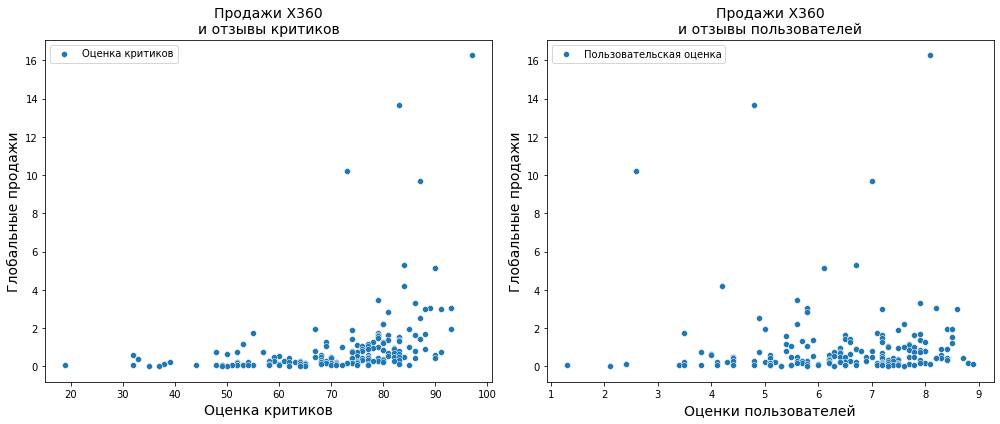

Корреляция отзывов критиков и продаж X360 : 0.3605734888507336
Корреляция отзывов пользователей и продаж X360 : -0.0020140394826897853


In [31]:
sales_corr("X360", release_2012) # применение функции

Есть слабая корреляция между продажами и оценками критиков, корреляция с пользовательскими оценками очень слабая. Далее рассмотрим прочие платформы из списка топов

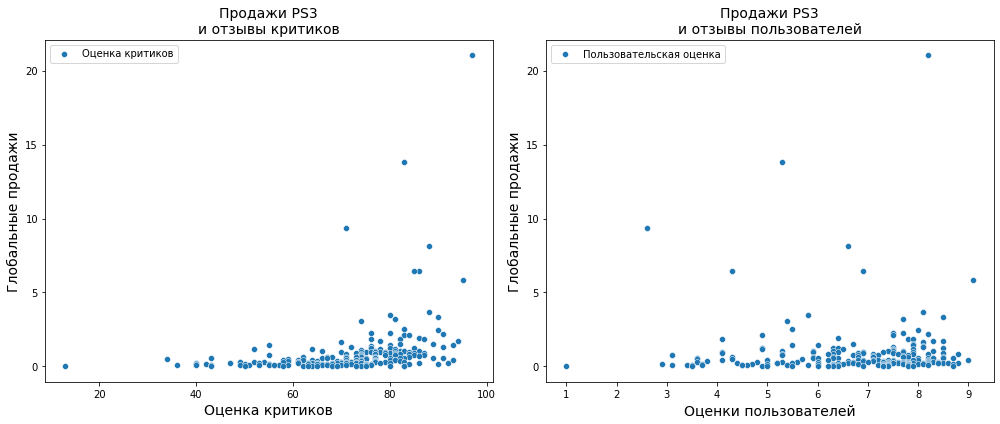

Корреляция отзывов критиков и продаж PS3 : 0.3310566175801407
Корреляция отзывов пользователей и продаж PS3 : 0.00322740549303569


In [32]:
sales_corr("PS3", release_2012) # рассмотрим PS3

PS3. Есть слабая корреляция между продажами и оценками критиков, а связь с пользовательскими оценками отсутствует.

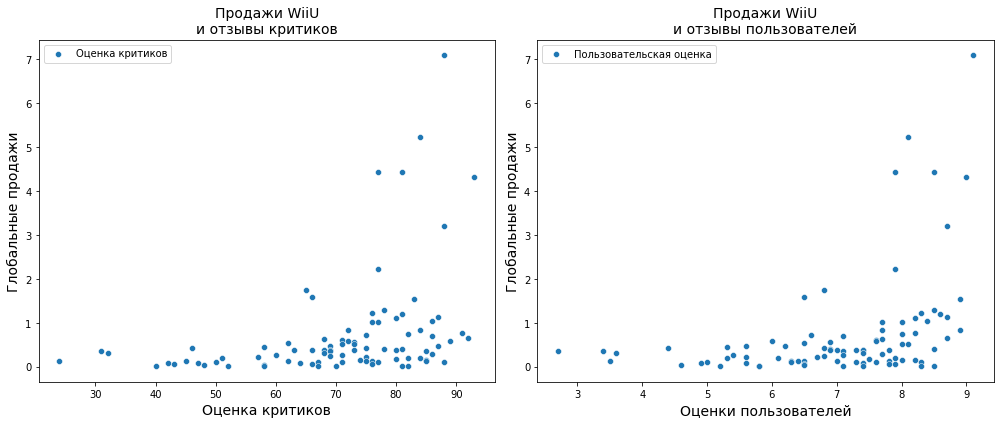

Корреляция отзывов критиков и продаж WiiU : 0.350882422488643
Корреляция отзывов пользователей и продаж WiiU : 0.3918479505297129


In [33]:
sales_corr("WiiU", release_2012) # рассмотрим WiiU

Для WiiU коэффициент корреляции с критиками снизился, а связь с оценками пользователей стала примерно равной или чуть выше.

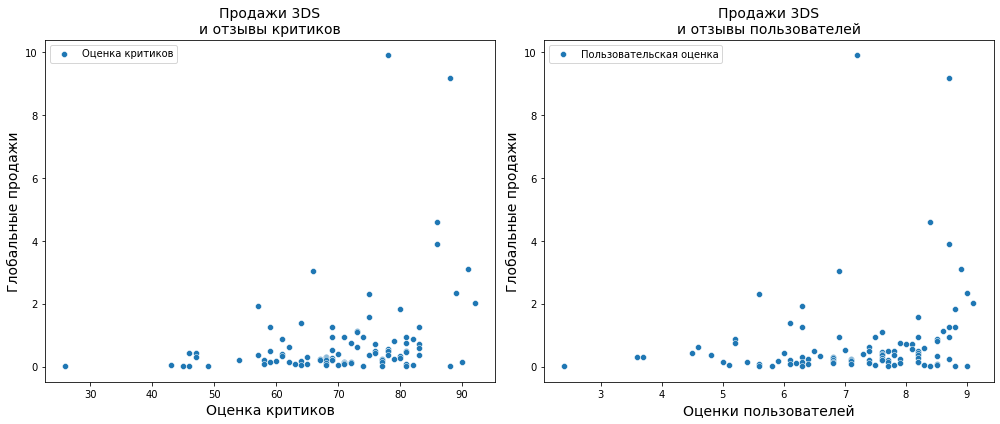

Корреляция отзывов критиков и продаж 3DS : 0.31055301915326294
Корреляция отзывов пользователей и продаж 3DS : 0.20181255007655283


In [34]:
sales_corr("3DS", release_2012) # рассмотрим 3DS

Есть небольшая зависимость продаж от оценок критиков и пользователей.

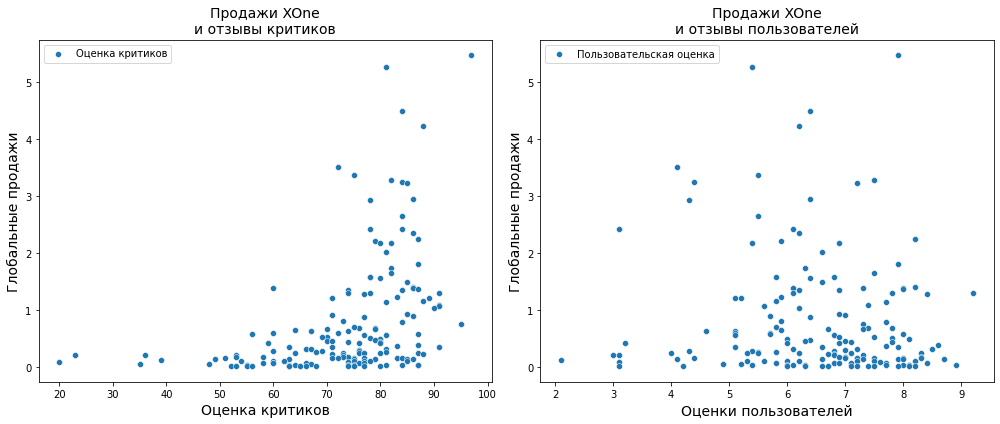

Корреляция отзывов критиков и продаж XOne : 0.41042203561296375
Корреляция отзывов пользователей и продаж XOne : -0.09400318326920852


In [35]:
sales_corr("XOne", release_2012) # рассмотрим для XOne

У платформы XOne наблюдается самый высокий коэффициент зависимости продаж от оценок критиков среди всех исследуемых.

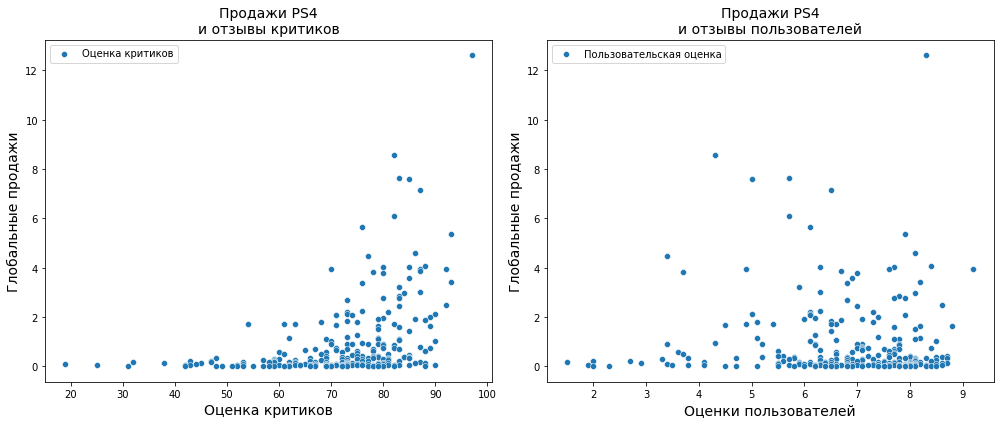

Корреляция отзывов критиков и продаж PS4 : 0.40589480145836687
Корреляция отзывов пользователей и продаж PS4 : -0.03362497596528878


In [36]:
sales_corr("PS4", release_2012) # рассмотрим PS4

В целом, анализ показывает, что продажи сильнее связаны с оценками критиков: чем выше оценки, тем выше продажи. В то же время, связь с пользовательскими оценками отсутствует.

In [37]:
release_2012.info() # просмотр информации

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2886 entries, 0 to 2885
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            2886 non-null   int64  
 1   name             2886 non-null   object 
 2   platform         2886 non-null   object 
 3   year_of_release  2886 non-null   Int64  
 4   genre            2886 non-null   object 
 5   na_sales         2886 non-null   float64
 6   eu_sales         2886 non-null   float64
 7   jp_sales         2886 non-null   float64
 8   other_sales      2886 non-null   float64
 9   critic_score     1312 non-null   float64
 10  user_score       1531 non-null   float64
 11  rating           1611 non-null   object 
 12  total            2886 non-null   float64
dtypes: Int64(1), float64(7), int64(1), object(4)
memory usage: 296.1+ KB


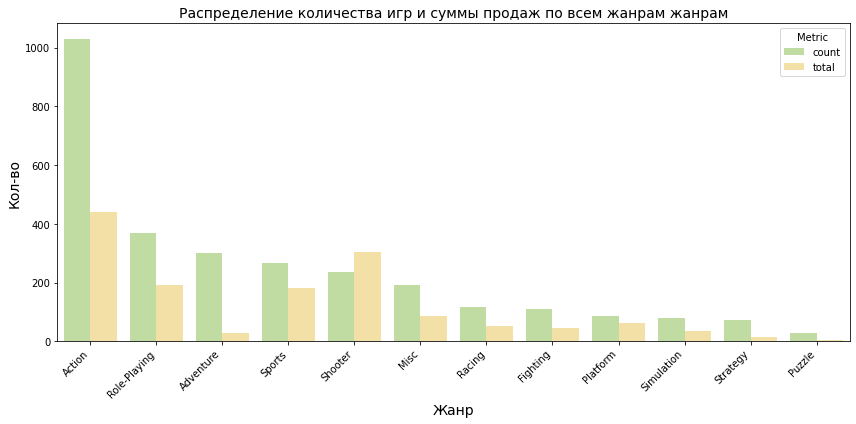

In [38]:
genre_count = release_2012["genre"].value_counts().reset_index().rename(columns = {"index": "genre", "genre": "count"}) # Группировка по жанрам и подсчет количества игр 
genre_sales  = release_2012.groupby("genre")["total"].sum().sort_values(ascending = False).reset_index() # Группировка по жанрам и суммирование продаж 
genre_all = pd.merge(genre_count, genre_sales, on = "genre") # мёрдж
genre_all = genre_all.sort_values(by = "count", ascending = False) # сортировка

plt.figure(figsize = (12, 6))
sns.barplot(data=genre_all.melt(id_vars = "genre", var_name = 'Metric', value_name = "Value"), x = "genre", y = "Value", hue = "Metric", palette=["#c2e699", "#ffe699"])
plt.title('Распределение количества игр и суммы продаж по всем жанрам жанрам', fontsize = 14)
plt.xlabel("Жанр", fontsize = 14) # проектирование метрик
plt.ylabel("Кол-во", fontsize = 14)
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

На графике видно, что наиболее распространённый жанр — Action, который также показывает самые высокие суммы продаж. Следующими по популярности и выручке идут жанры Sports и Shooter, причём у Shooter лучшее соотношение продаж к выручке. Самые низкие показатели по продажам и выручке у жанров Strategy и Puzzle — спокойных жанров, в то время как активные жанры занимают верхние позиции.

Поскольку высокие продажи могут быть связаны не только с успехом, а также с большим количеством игр, проанализируем средние показатели продаж. Построим боксплоты для оценки распределения продаж по жанрам.

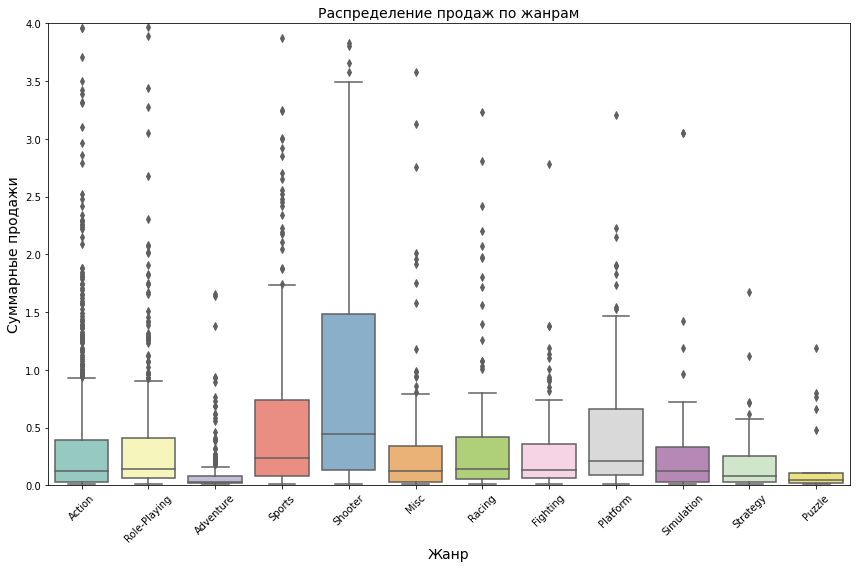

In [39]:
sort_games = genre_count.sort_values(by = "count", ascending = False)["genre"] # сортировка по кол-ву игр

plt.figure(figsize = (12, 8)) # проектирование метрик
sns.boxplot(x = "genre", y = "total", data = release_2012, order = sort_games, palette = "Set3")
plt.title("Распределение продаж по жанрам", fontsize = 14)
plt.xlabel('Жанр', fontsize = 14)
plt.ylabel("Суммарные продажи", fontsize = 14)
plt.xticks(rotation = 45)
plt.ylim(0, 4)
plt.tight_layout()
plt.show()

В жанре Action много выбросов, что объясняет его высокую доходность. Медианные продажи наиболее высоки у жанра Shooter, затем Platform и Sports, а у Adventure — самые низкие.

Анализ показал, что до 1990-х индустрия развивалась медленно, затем начался активный рост с пиком в 2008–2009 годах. В 2012 году произошёл резкий спад, и к 2016 году выпуск игр стабилизировался около 550 в год. Исследование платформ показало, что активная «жизнь» каждой длится примерно 10 лет. За период с 2005 по 2016 год лидируют X360, PS3, Wii, DS, PS2 и PS4. Медианные продажи на платформу варьируются от 0,15 до 0,28 млн за игру; на каждой есть аномально успешные игры.

Анализ зависимости продаж от оценок показал, что они сильнее связаны с оценками критиков: чем выше оценки — тем выше продажи. Связь с пользовательскими оценками отсутствует. В целом, больше игр выпускается в активных жанрах (Action), которые также показывают самые высокие суммы продаж

# Портрет пользователя региона 

In [40]:
na_sales = release_2012.groupby("platform")["na_sales"].sum().sort_values(ascending=False).head(5) # группировка по платформам + суммирование
eu_sales = release_2012.groupby("platform")["eu_sales"].sum().sort_values(ascending=False).head(5)
jp_sales = release_2012.groupby("platform")["jp_sales"].sum().sort_values(ascending=False).head(5)

print("Топ в NA:")
print(na_sales)
print("Топ в EU:") # Вывод топ-5
print(eu_sales) 
print("Топ в JP:")
print(jp_sales)

Топ в NA:
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64
Топ в EU:
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64
Топ в JP:
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


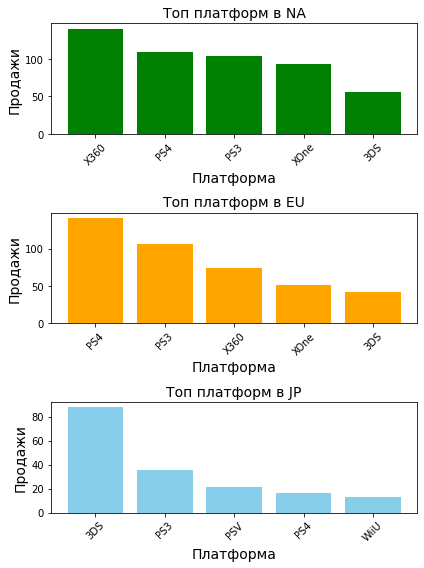

In [41]:
fig, axes = plt.subplots(3, 1, figsize = (6, 8)) # задаём график

axes[0].bar(na_sales.index, na_sales.values, color = "green")
axes[0].set_title("Топ платформ в NA", fontsize = 14)
axes[0].set_xlabel("Платформа", fontsize = 14) # График для NA
axes[0].set_ylabel("Продажи", fontsize = 14)
axes[0].tick_params(axis = "x", rotation = 45)

axes[1].bar(eu_sales.index, eu_sales.values, color = "orange")
axes[1].set_title("Топ платформ в EU", fontsize = 14)
axes[1].set_xlabel("Платформа", fontsize = 14) # график для EU
axes[1].set_ylabel("Продажи", fontsize = 14)
axes[1].tick_params(axis = "x", rotation = 45)

axes[2].bar(jp_sales.index, jp_sales.values, color = "skyblue")
axes[2].set_title("Топ платформ в JP", fontsize = 14)
axes[2].set_xlabel("Платформа", fontsize = 14) # график для JP
axes[2].set_ylabel("Продажи", fontsize = 14)
axes[2].tick_params(axis = "x", rotation = 45)

plt.tight_layout()
plt.show() # вывод графика

In [42]:
na_sum = release_2012["na_sales"].sum()
eu_sum = release_2012["eu_sales"].sum() #  ссуммируем продажи по регионам 
jp_sum = release_2012["jp_sales"].sum()

na_sum_part = na_sales / na_sum * 100 # вычисление долей по регионам 
eu_sum_part = eu_sales / eu_sum * 100
jp_sum_part = jp_sales / jp_sum * 100

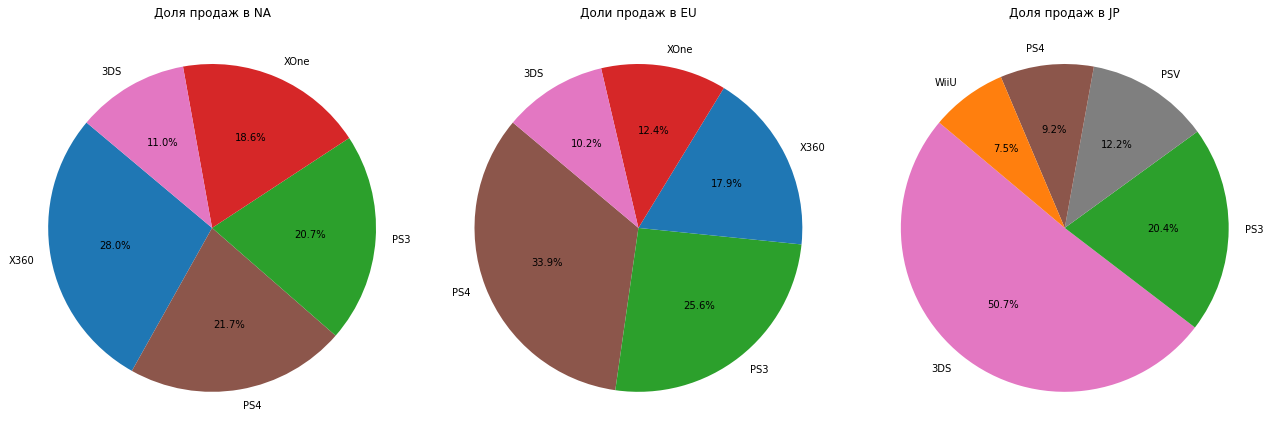

In [43]:
colors = {
    'X360': 'tab:blue',
    'WiiU': 'tab:orange',
    'PS3': 'tab:green',
    'XOne': 'tab:red',
    'PS2': 'tab:purple',
    'PS4': 'tab:brown',
    '3DS': 'tab:pink',
    'PSV': 'tab:gray'
} # список для цвета

fig, axes = plt.subplots(1, 3, figsize = (18, 6)) # задаём сетку

na_plat  = na_sum_part.index # подготовка данных
na_bar = na_sum_part.values

eu_plat = eu_sum_part.index # подготовка данных
eu_bar = eu_sum_part.values

jp_plat = jp_sum_part.index # подготовка данных
jp_bar = jp_sum_part.values


axes[0].pie(na_bar, labels = na_plat, autopct = "%1.1f%%", startangle = 140, colors = [colors[p]\
                                                                                            for p in na_plat])
axes[0].set_title("Доля продаж в NA") # проектирование для NA


axes[1].pie(eu_bar, labels = eu_plat, autopct = "%1.1f%%", startangle = 140, colors = [colors[p]\
                                                                                            for p in eu_plat])
axes[1].set_title("Доли продаж в EU") # проектирование для EU


axes[2].pie(jp_bar, labels = jp_plat, autopct = "%1.1f%%", startangle = 140, colors=[colors[p]\
                                                                                            for p in jp_plat])
axes[2].set_title("Доля продаж в JP") # проектирование для JP

plt.tight_layout()
plt.show() # отображение 


В NA и EU лидируют X360, PS4, PS3, XOne и 3DS, лишь с разным расположением. В JP доминирует 3DS, на втором месте — PS3, также есть PSV и WiiU, которых нет в EU и NA.

In [44]:
na_sales_sum = release_2012.groupby("genre")["na_sales"].sum().sort_values(ascending=False).head(5) 
# группировка по жанрам и суммирование продаж
eu_sales_sum = release_2012.groupby("genre")["eu_sales"].sum().sort_values(ascending=False).head(5)
jp_sales_sum = release_2012.groupby("genre")["jp_sales"].sum().sort_values(ascending=False).head(5)

# Вывод топ-5 жанров для NA, EU, JP
print("Топ-5 в NA:")
print(na_sales_sum)
print("\nТоп-5 в EU:")
print(eu_sales_sum)
print("\nТоп-5 в JP:")
print(jp_sales_sum)

Топ-5 в NA:
genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

Топ-5 в EU:
genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

Топ-5 в JP:
genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64


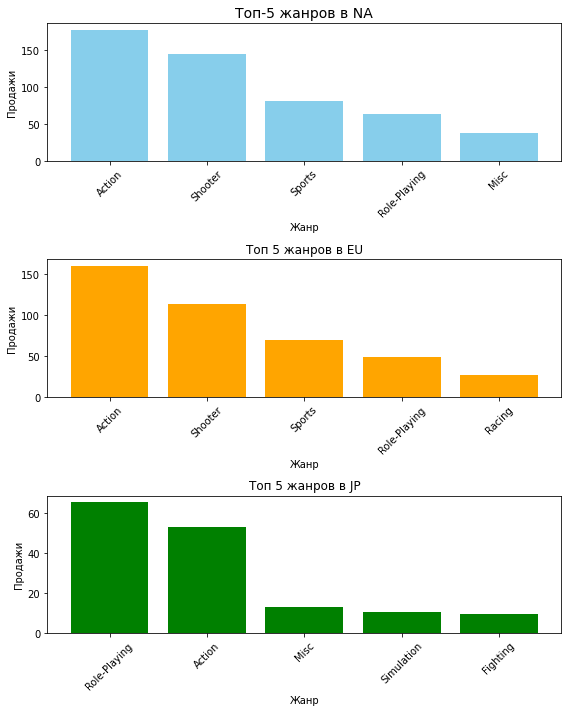

In [45]:
fig, axes = plt.subplots(3, 1, figsize = (8, 10)) # задаём графики 
 
axes[0].bar(na_sales_sum.index, na_sales_sum.values, color = "skyblue")
axes[0].set_title("Топ-5 жанров в NA", fontsize = 14)
axes[0].set_xlabel("Жанр") # график для NA
axes[0].set_ylabel("Продажи")
axes[0].tick_params(axis = "x", rotation = 45)

axes[1].bar(eu_sales_sum.index, eu_sales_sum.values, color = "orange")
axes[1].set_title("Топ 5 жанров в EU")
axes[1].set_xlabel("Жанр") # график для EU
axes[1].set_ylabel("Продажи")
axes[1].tick_params(axis = "x", rotation = 45)

axes[2].bar(jp_sales_sum.index, jp_sales_sum.values, color= "green")
axes[2].set_title(("Топ 5 жанров в JP")) # график для JP
axes[2].set_xlabel("Жанр") # график для JP
axes[2].set_ylabel("Продажи")
axes[2].tick_params(axis = "x", rotation = 45)

plt.tight_layout()
plt.show()

В NA и EU лидируют активные и динамичные жанры — Action, Shooter и Sports. В JP же доминируют ролевые игры, а Action занимает второе место.

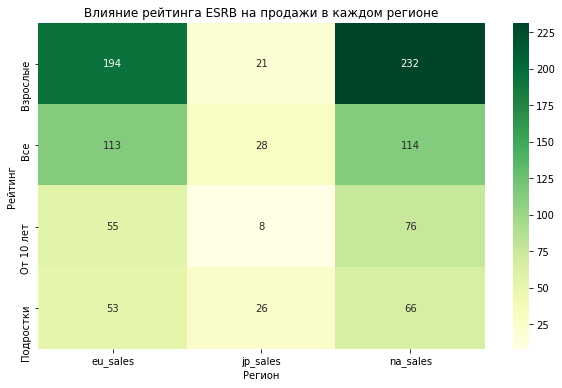

In [46]:
rat_drop = release_2012.dropna(subset = ["rating"]) # удаление пропусков 
corr_mat = rat_drop[["na_sales", "eu_sales", "jp_sales", "rating"]].pivot_table(index = "rating", aggfunc = "sum")
# построение матрицы для каждого региона

plt.figure(figsize = (10, 6)) # проектирование хитмэпа
sns.heatmap(corr_mat, annot = True, cmap = "YlGn", fmt = ".0f")
plt.title("Влияние рейтинга ESRB на продажи в каждом регионе")
plt.xlabel("Регион")
plt.ylabel("Рейтинг")
plt.show()

Тепловая карта показывает, что в NA и EU наиболее популярны категории игр «Для взрослых», затем «Для всех», «От 10 лет и старше» и «Подросткам». В Японии лидирует категория «Для всех», а «Для взрослых» — на втором месте; категории для малышей практически отсутствуют.

Портрет пользователя NA: самая популярная платформа — Xbox 360 (28%), далее PS4 (21,7%), PS3 и XOne примерно одинаковы, и 3DS — 11%. Жанры — Action, Shooter и Sport. В основном играют в игры для взрослых.

Пользователь EU: лидирует PS4 (33,9%), затем PS3 (25,6%), далее Xbox 360 и XOne, 3DS — 10,2%. Жанры те же — Action, Shooter и Sport. Предпочитают игры для взрослых.

Пользователь JP: самая популярная платформа — 3DS (50,7%), далее PS3 (20,4%), затем PS4 и PSV, WiiU — 7,5%. Основной жанр — Role-Playing, затем Action. В основном выбирают игры «Для всех».

# Проверка гипотез

Первая гипотеза: средние пользовательские рейтинги платформ Xbox One и PC равны.

Нулевая гипотеза (H0): средние рейтинги Xbox One и PC совпадают.
Альтернативная гипотеза (H1): средние рейтинги этих платформ отличаются.
Уровень значимости установлен на 0,05.
Для проверки используем t-тест для независимых выборок.

In [47]:
xbox = release_2012[(release_2012["platform"] == "XOne") & (~release_2012["user_score"]\
                                                                         .isnull())]["user_score"] # фильтрация, удаление пропущенных значений
pc = release_2012[(release_2012["platform"] == "PC") & (~release_2012["user_score"]\
                                                                     .isnull())]["user_score"]
t_statistic, p_value = st.ttest_ind(xbox, pc) # проведение теста
alpha = 0.05 # значимость

print(f"P-value: {p_value:.4f}") # вывод p value

if p_value < alpha: 
    print("Отвергаем нулевую гипотезу: средние пользовательские рейтинги Xbox One и PC различаются.")
else:
    print("Не отвергаем нулевую гипотезу: нет достаточных доказательств различия средних пользовательских рейтингов\
    платформ Xbox One и PC.")

P-value: 0.5535
Не отвергаем нулевую гипотезу: нет достаточных доказательств различия средних пользовательских рейтингов    платформ Xbox One и PC.


Для проверки гипотезы о равенстве средних пользовательских рейтингов Xbox One и PC использовался t-тест для независимых выборок. При уровне значимости 0,05 результаты показали, что статистически значимых различий между средними рейтингами этих платформ нет, так как p-value превышает 0,05.

Вторая гипотеза: средние пользовательские оценки жанров Action (экшен-игры) и Sports (спортивные игры) отличаются.

Нулевая гипотеза (H0): средние пользовательские рейтинги жанров Action и Sports равны.
Альтернативная гипотеза (H1): средние пользовательские рейтинги этих жанров различаются.
Уровень значимости установлен на 0,05.
Для проверки используется t-тест для независимых выборок.

In [48]:
action = release_2012[(release_2012["genre"] == "Action") & (~release_2012["user_score"].isnull())]["user_score"]
sports = release_2012[(release_2012["genre"] == "Sports") & (~release_2012["user_score"].isnull())]["user_score"]
t_statistic, p_value = st.ttest_ind(action, sports)  # проведение теста

alpha = 0.05  # уровень значимости

print(f"P-value: {p_value:.4f}") # вывод p value
 
if p_value < alpha:
    print("Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports различаются.")
else:
    print("Не отвергаем нулевую гипотезу: нет достаточных доказательств различия средних пользовательских рейтингов жанров Action и Sports.")

P-value: 0.0000
Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports различаются.


Для проверки различия средних пользовательских рейтингов жанров Action и Sports использовался t-тест для независимых выборок. При уровне значимости 0,05 результаты показали статистически значимые различия, так как p-value было меньше 0,05.

# Вывод

В ходе проекта мы провели комплексный анализ исторических данных о продажах видеоигр, оценках пользователей и критиков, а также исследовали популярные платформы и жанры в трех ключевых регионах: Северной Америке (NA), Европе (EU) и Японии (JP). Ниже представлены основные выводы.

1. Обзор данных
Датасет охватывает период с 1980 по 2016 год. В процессе подготовки данных мы привели типы столбцов user_score и year_of_release к нужным форматам, стандартизировали названия столбцов и значений, а также изменили значения рейтингов для удобства анализа. Были обработаны пропуски, а также добавлен новый столбец — суммарные продажи по регионам.

2. Анализ выпуска игр
Количество новых игр росло с начала 1990-х годов, достигнув пика в 2008–2009 годах. После этого наблюдался спад, и к 2016 году ежегодное число выпусков стабилизировалось около 550 игр.
Рассмотрев топ-6 платформ за исследуемый период (2012–2016), выявили их средний «жизненный цикл» около 10 лет. В этот период лидируют PS4, PS3, Xbox 360 (X360), Nintendo 3DS, Xbox One (XOne) и Wii U.

3. Зависимость продаж от оценок
Анализ показал, что продажи игр сильнее зависят от оценки критиков: чем выше рейтинг критиков — тем выше продажи. В то же время связь между пользовательскими оценками и продажами оказалась слабой или отсутствующей.

4. Распределение по жанрам
Наибольшее количество игр выпускается в жанре Action, который также демонстрирует самые высокие суммы продаж. Однако медианное значение продаж лучше всего у жанра Shooter, что говорит о высокой стабильности успешных игр в этом жанре. В целом активные жанры (Action, Shooter, Sport) показывают лучшие показатели продаж по сравнению с более спокойными — Strategy и Puzzle.

5. Портреты пользователей по регионам

- Северная Америка: Самая популярная платформа — Xbox 360 (28%), далее PS4 (21,7%), PS3 и XOne примерно одинаково популярны; замыкает топ-5 3DS (11%). Основной жанр — Action; предпочтения склоняются к активным и захватывающим играм для взрослых.
- Европа: Лидирует PS4 (33,9%), затем PS3 (25,6%), далее X360 и XOne; 3DS — около 10%. Предпочитаемые жанры — Action, Shooter и Sport; также ориентированы на игры для взрослых.
- Япония: Наиболее популярна платформа 3DS (50,7%), затем PS3 (20,4%), а также PS4 и PSV; Wii U занимает около 7,5%. Основной жанр — Role-Playing Games; предпочтения склоняются к играм для всех возрастов.
6. Проверка гипотез
Проведенные t-тесты показали:
- Нет статистически значимых различий в средних пользовательских рейтингах платформ Xbox One и PC.
- Средние пользовательские оценки жанров Action и Sports действительно отличаются.
- Региональные особенности предпочтений
- Понимание региональных предпочтений важно для планирования маркетинговых стратегий:
- В Европе и Северной Америке доминируют активные жанры — Action и Sport.
- В Японии предпочитают более спокойные и интеллектуальные игры — Strategy и Puzzle.
- Игры для всех возрастов пользуются большей популярностью во всех регионах; категории для детей до 10 лет показывают низкий спрос.
- Перспективные платформы на конец 2016 года
PS4: остается лидером благодаря постоянному развитию бренда Sony; наиболее популярен в Европе и других регионах.
XOne: имеет потенциал роста в Европе и Северной Америке.
Япония: сохраняет актуальность своих локальных платформ — Nintendo 3DS остается наиболее популярной.
7. Заключение: Анализ показал важность региональных особенностей при планировании маркетинговых кампаний и выборе платформ для продвижения игр. Успех зависит не только от технических характеристик устройств или жанровых предпочтений, но также от понимания культурных особенностей аудитории каждого региона.